# Phân tích sentiment của comments trong các videos TIKTOK

## Tìm các comments có nhiều luợt tim nhất trong mỗi video

In [112]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
from pprint import pprint
import numpy as np
from collections import defaultdict
from underthesea import word_tokenize
import urllib.request
import regex
import os

In [ ]:
metadata_path = Path("content_metadata")

files = []

for file_path in metadata_path.rglob("*.json"):
    files.append(file_path)
print(f'[LOG] Tổng số files: {len(files)}')

[LOG] Tổng số files: 274


In [ ]:
with open(files[100], 'r') as f:
    test_sample = json.load(f)
pprint(test_sample)

In [18]:
print(test_sample['comment_metadata']['comments'][0]['like_count'])
print(test_sample['comment_metadata']['comments'][0]['total_reply'])

7858
214


Sử dụng thuật toán Quick Select để tìm ra top-k bình luận có luợt tim nhiều nhất

In [ ]:
import random

def quick_select(comments, k):

    if not comments or k <= 0:
        return []

    if k >= len(comments):
        return comments

    def partition(left, right):
        pivot_index = random.randint(left, right)
        pivot_value = comments[pivot_index].get("like_count", 0)

        # Đưa pivot về cuối
        comments[pivot_index], comments[right] = comments[right], comments[pivot_index]

        store_index = left

        # Partition: lớn hơn pivot đưa về bên trái
        for i in range(left, right):
            if comments[i].get("like_count", 0) > pivot_value:
                comments[i], comments[store_index] = comments[store_index], comments[i]
                store_index += 1

        # Đưa pivot về đúng vị trí
        comments[store_index], comments[right] = comments[right], comments[store_index]

        return store_index

    def select(left, right, k_index):
        if left == right:
            return

        pivot_index = partition(left, right)

        if k_index == pivot_index:
            return
        elif k_index < pivot_index:
            select(left, pivot_index - 1, k_index)
        else:
            select(pivot_index + 1, right, k_index)

    select(0, len(comments) - 1, k - 1)

    # Lấy k phần tử đầu
    top_k = comments[:k]

    return top_k

Tìm top comment theo lượt tim (chạy mẫu 1 sample)

In [110]:
k=100
for file in files[221:222]:
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)
    comment_metadata = data['comment_metadata']
    if not comment_metadata:
        continue
    comments = comment_metadata.get("comments", [])

    top_comments = quick_select(comments, k)

    print(f"\nFile: {file}")
    for c in top_comments:
        print(f"Like: {c.get('like_count',0)} | Text: {c.get('comment','')[:50]} (len:{count_words(c.get('comment', ''))})")


File: content_metadata/Adult Content/kienthuckhoahoc64_7589239042718453023.json
Like: 680 | Text: Hay thò tay vuốt vuốt (len:5)
Like: 103 | Text: Tao con gái cũng có lông mà (len:7)
Like: 96 | Text: Thế méo nào t con gái cũng có, có cả trái cổ luôn  (len:14)
Like: 456 | Text: Thằng nào cũng có mà 🤣🤣 (len:6)
Like: 4 | Text: Lông tóc mọc ở đâu cũng đều có lý do. Vậy sso con  (len:19)
Like: 9 | Text: Á đù t cũng hay hỏi ck sao lại có chỗ đó (len:12)
Like: 40 | Text: Rảnh rảnh t cũng hay thò tay t nhổ:)) (len:9)
Like: 1 | Text: Tui cũng thắt mắt vậy tại sao ck tui có long chỗ đ (len:29)
Like: 38 | Text: Ê bây ơi t nhiều lắm (len:6)
Like: 3 | Text: T lấy tay nhổ lên mũi ngửi (len:7)
Like: 47 | Text: Ai nằm trong 30% đó giơ tay nè😂 (len:8)
Like: 1 | Text: tôi có vậy là 30% trên thế giới rồi,may lướt top t (len:14)
Like: 4 | Text: 30% đó có Tao...đôi khi cũng thấy ớn ớn.. nhưng ng (len:16)
Like: 1 | Text: T cạo r , nó cạ đau đau khó chịu ấy nên lần sau t  (len:18)
Like: 5 | Text: thế mà mình

## Phân tích độ dài của comments theo lượt tim

In [67]:
def count_words(text):
    return len(text.split())

def avg_comment_length(comments):
    if not comments:
        return 0
    lengths = [count_words(c.get('comment', '')) for c in comments]
    return sum(lengths) / len(lengths)

def visualize_distribution(overall_avg_lengths, top_avg_lengths):
    overall_mean = np.mean(overall_avg_lengths)
    top_mean = np.mean(top_avg_lengths)

    # Biểu đồ 1: Overall
    plt.figure(figsize=(8, 5))
    plt.hist(overall_avg_lengths, bins=40, alpha=0.6, color='steelblue', label='Overall')
    plt.axvline(overall_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {overall_mean:.2f}')
    plt.title("Distribution of Average Comment Length (Overall)")
    plt.xlabel("Average Comment Length")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Biểu đồ 2: Top-k
    plt.figure(figsize=(8, 5))
    plt.hist(top_avg_lengths, bins=40, alpha=0.6, color='orange', label=f'Top-{k}')
    plt.axvline(top_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {top_mean:.2f}')
    plt.title(f"Distribution of Average Comment Length (Top-{k})")
    plt.xlabel("Average Comment Length")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

**So sánh trung bình độ dài của các videos trong top-k lượt tim và trung bình tổng thể**

Total videos used: 265


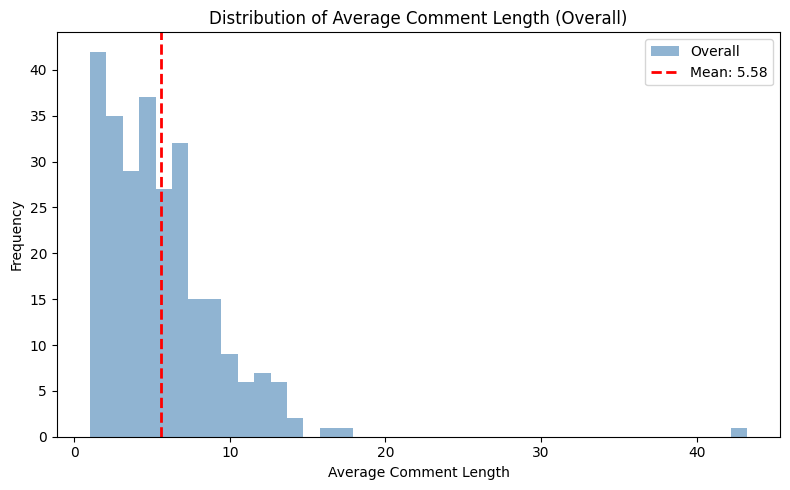

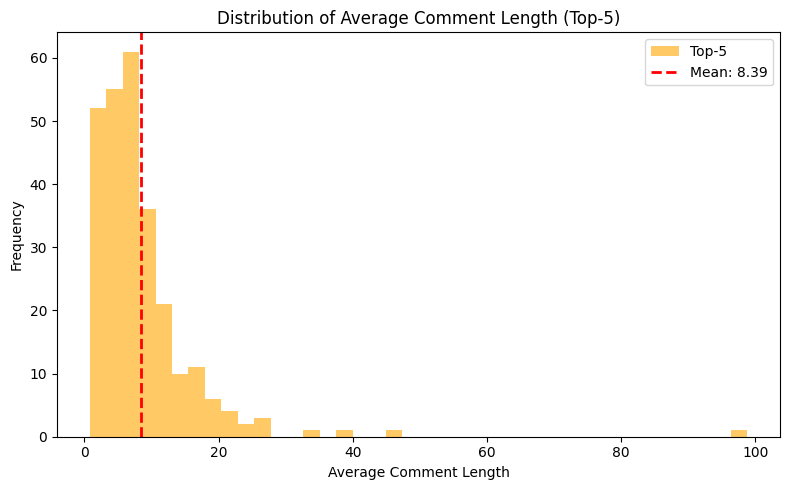

In [ ]:
k=5
top_avg_lengths = []
overall_avg_lengths = []
for file in files:
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)
        
    comment_metadata = data['comment_metadata']
    if not comment_metadata:
        continue
    
    comments = comment_metadata.get("comments", [])
    if not comments:
        continue

    # Tính trung bình trên tất cả comments
    overall_avg = avg_comment_length(comments)
    overall_avg_lengths.append(overall_avg)
    
    # Tính trung bình trên các comments được yêu thích nhất
    top_comments = quick_select(comments, k)
    top_avg = avg_comment_length(top_comments)
    top_avg_lengths.append(top_avg)
print("Total videos used:", len(top_avg_lengths))


visualize_distribution(overall_avg_lengths, top_avg_lengths)

## So sánh tỉ lệ emojies/comment theo từng nhóm

In [108]:
count_emojis('chồng bỏ vợ ở nhà vợ 🪝🦋 1 mình 😭 ')

3

In [105]:
def count_emojis(text):
    """Đếm số emoji trong một chuỗi văn bản"""
    emoji_pattern = regex.compile(r'\p{Extended_Pictographic}', regex.UNICODE)
    return len(emoji_pattern.findall(text))

def emoji_ratio_per_video(comments):
    """
    Tính tỉ lệ: tổng emoji / tổng số comments của 1 video
    Trả về 0 nếu không có comment nào
    """
    if not comments:
        return 0.0
    total_emojis = sum(count_emojis(c.get("comment", "")) for c in comments)
    return total_emojis / len(comments)

In [109]:
emoji_by_label = defaultdict(list)  # { "Adult Content": [0.3, 0.1, ...], ... }

for file in files:
    label = os.path.basename(os.path.dirname(file))
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)

    comment_metadata = data.get("comment_metadata")
    if not comment_metadata:
        continue

    comments = comment_metadata.get("comments", [])
    if not comments:
        continue

    ratio = emoji_ratio_per_video(comments)
    emoji_by_label[label].append(ratio)

# -------------------------------------------------------
# In thống kê tổng hợp
# -------------------------------------------------------
print(f"{'label':<25} {'Videos':>7} {'Mean':>8} {'Median':>8} {'Std':>8}")
print("-" * 60)
for label, ratios in sorted(emoji_by_label.items()):
    print(f"{label:<25} {len(ratios):>7} {np.mean(ratios):>8.4f} "
          f"{np.median(ratios):>8.4f} {np.std(ratios):>8.4f}")

label                      Videos     Mean   Median      Std
------------------------------------------------------------
Adult Content                  69   1.3158   1.1077   1.0301
Harmful Content                62   1.4132   0.9125   2.1945
Safe                          100   1.0790   0.8327   1.6255
Suicide                        34   1.0784   0.8550   0.8302


## Phân tích Word Cloud

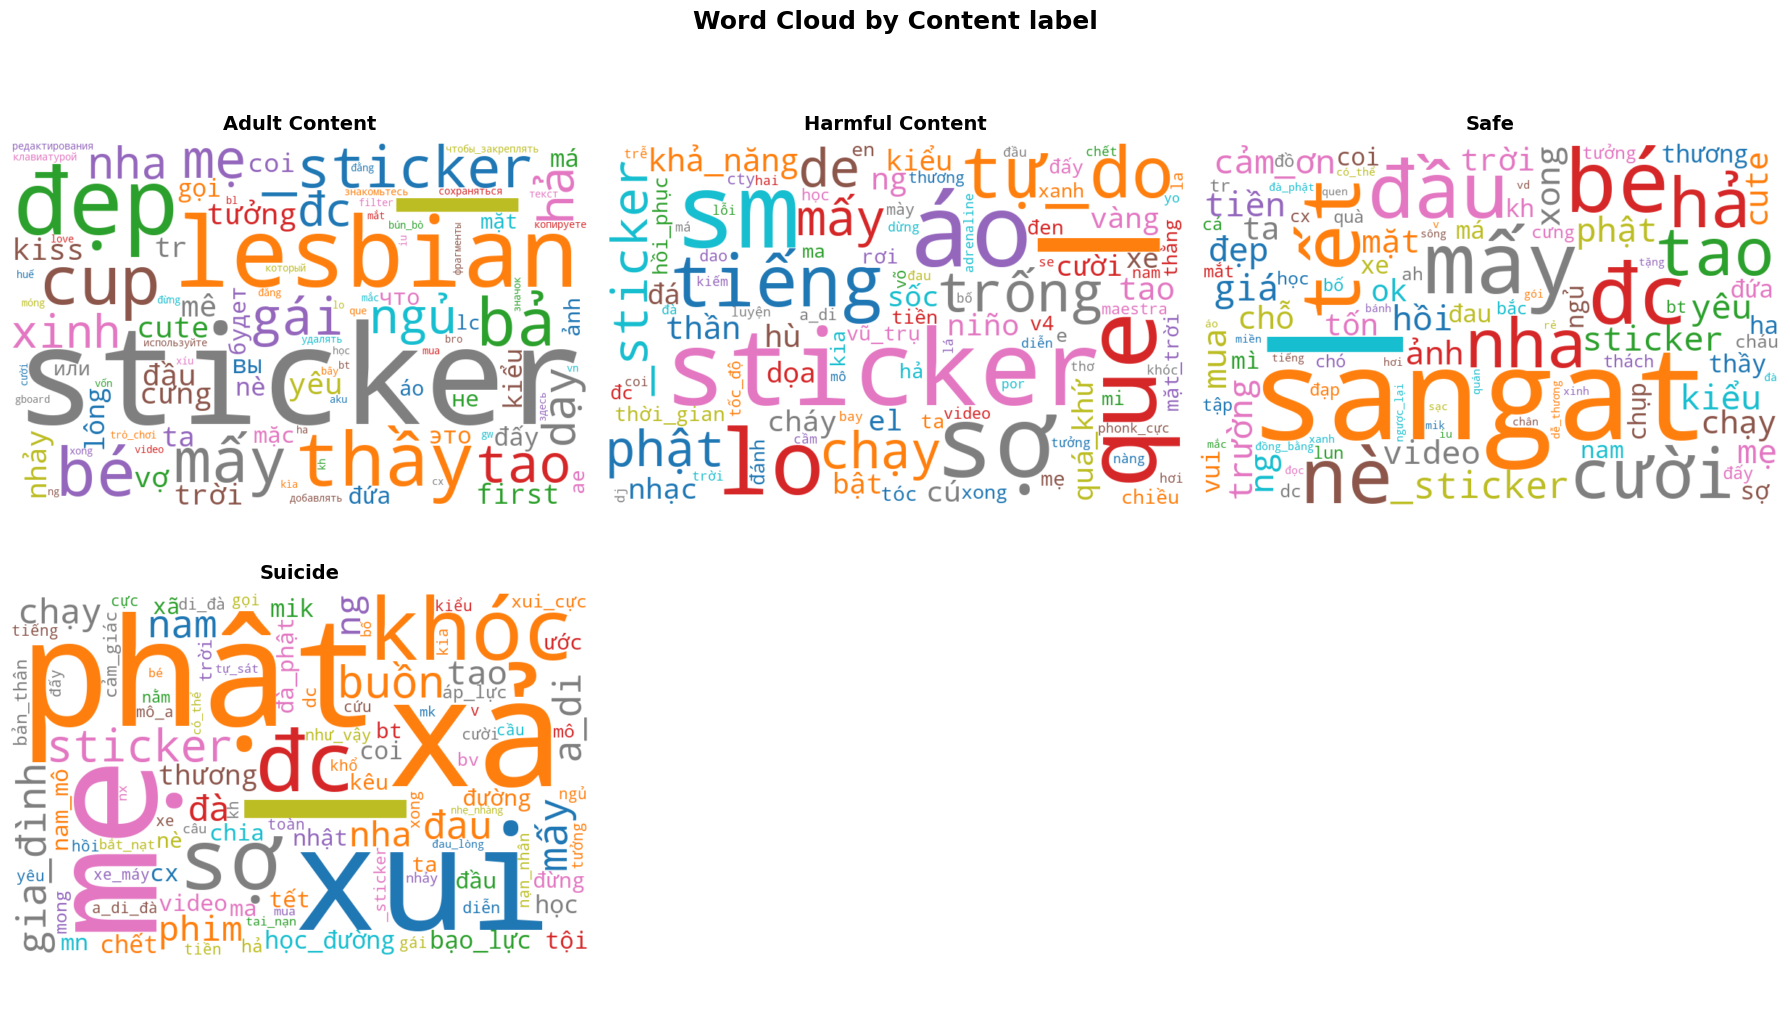

In [ ]:
from wordcloud import WordCloud, STOPWORDS

STOPWORDS_URL = "https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/master/vietnamese-stopwords.txt"
with urllib.request.urlopen(STOPWORDS_URL) as response:
    VI_STOPWORDS = set(response.read().decode("utf-8").splitlines())

CUSTOM_STOPWORDS = set([
    "ko", "tui", "đi", "lắm"
])

ALL_STOPWORDS = STOPWORDS.union(VI_STOPWORDS).union(CUSTOM_STOPWORDS)


def preprocess_text(text):
    """Tách từ tiếng Việt đúng cụm (underthesea) rồi lọc stopwords"""
    tokens = word_tokenize(text, format="text").split()
    tokens = [t.lower() for t in tokens if t.lower() not in ALL_STOPWORDS and len(t) > 1]
    return " ".join(tokens)

def get_all_text_by_label(files):
    """Gom toàn bộ text comments theo từng label"""
    text_by_label = defaultdict(list)

    for file in files:
        label = os.path.basename(os.path.dirname(file))
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)

        comment_metadata = data.get("comment_metadata")
        if not comment_metadata:
            continue

        comments = comment_metadata.get("comments", [])
        for c in comments:
            text = c.get("comment", "").strip()
            if text:
                text_by_label[label].append(preprocess_text(text))

    return text_by_label


def draw_wordclouds(text_by_label):
    labels = sorted(text_by_label.keys())
    n = len(labels)
    
    # Tính số hàng/cột cho subplot
    ncols = 3
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 5))
    axes = axes.flatten()

    for i, label in enumerate(labels):
        all_text = " ".join(text_by_label[label])

        wc = WordCloud(
            width=800,
            height=500,
            background_color="white",
            max_words=100,
            colormap="tab10",
            collocations=False,  # Tránh lặp cụm từ
            regexp=r"\w+",       # Tách từ, bỏ emoji nếu muốn giữ text thuần
        ).generate(all_text)

        axes[i].imshow(wc, interpolation="bilinear")
        axes[i].axis("off")
        axes[i].set_title(label, fontsize=14, fontweight="bold", pad=10)

    # Ẩn các subplot thừa
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Word Cloud by Content label", fontsize=18, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


# ── Chạy ──────────────────────────────────────────────
text_by_label = get_all_text_by_label(files)
draw_wordclouds(text_by_label)